This is a companion notebook for the book [Deep Learning with Python, Third Edition](https://www.manning.com/books/deep-learning-with-python-third-edition). For readability, it only contains runnable code blocks and section titles, and omits everything else in the book: text paragraphs, figures, and pseudocode.

**If you want to be able to follow what's going on, I recommend reading the notebook side by side with your copy of the book.**

The book's contents are available online at [deeplearningwithpython.io](https://deeplearningwithpython.io).

In [0]:
!pip install keras keras-hub --upgrade -q

In [1]:
import os
os.environ["KERAS_BACKEND"] = "jax"

In [2]:
# @title
import os
from IPython.core.magic import register_cell_magic

@register_cell_magic
def backend(line, cell):
    current, required = os.environ.get("KERAS_BACKEND", ""), line.split()[-1]
    if current == required:
        get_ipython().run_cell(cell)
    else:
        print(
            f"This cell requires the {required} backend. To run it, change KERAS_BACKEND to "
            f"\"{required}\" at the top of the notebook, restart the runtime, and rerun the notebook."
        )

## Fundamentals of machine learning

### Generalization: The goal of machine learning

#### Underfitting and overfitting

##### Noisy training data

##### Ambiguous features

##### Rare features and spurious correlations

In [5]:
from keras.datasets import mnist
import numpy as np

(train_images, train_labels), _ = mnist.load_data()
train_images = train_images.reshape((60000, 28 * 28))
train_images = train_images.astype("float32") / 255

train_images_with_noise_channels = np.concatenate(
    [train_images, np.random.random((len(train_images), 784))], axis=1
)

train_images_with_zeros_channels = np.concatenate(
    [train_images, np.zeros((len(train_images), 784))], axis=1
)

In [6]:
import keras
from keras import layers

def get_model():
    model = keras.Sequential(
        [
            layers.Dense(512, activation="relu"),
            layers.Dense(10, activation="softmax"),
        ]
    )
    model.compile(
        optimizer="adam",
        loss="sparse_categorical_crossentropy",
        metrics=["accuracy"],
    )
    return model

model = get_model()
history_noise = model.fit(
    train_images_with_noise_channels,
    train_labels,
    epochs=10,
    batch_size=128,
    validation_split=0.2,
)

model = get_model()
history_zeros = model.fit(
    train_images_with_zeros_channels,
    train_labels,
    epochs=10,
    batch_size=128,
    validation_split=0.2,
)

Epoch 1/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.8692 - loss: 0.4357 - val_accuracy: 0.9197 - val_loss: 0.2866
Epoch 2/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9319 - loss: 0.2285 - val_accuracy: 0.9418 - val_loss: 0.2029
Epoch 3/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9537 - loss: 0.1567 - val_accuracy: 0.9383 - val_loss: 0.2012
Epoch 4/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9682 - loss: 0.1086 - val_accuracy: 0.9567 - val_loss: 0.1522
Epoch 5/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9759 - loss: 0.0801 - val_accuracy: 0.9586 - val_loss: 0.1421
Epoch 6/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9836 - loss: 0.0569 - val_accuracy: 0.9566 - val_loss: 0.1468
Epoch 7/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9890 - loss: 0.0398 - val_accuracy: 0.9521 - val_loss: 0.1670
Epoch 8/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9917 - loss: 0.0302 - val_accuracy: 0.

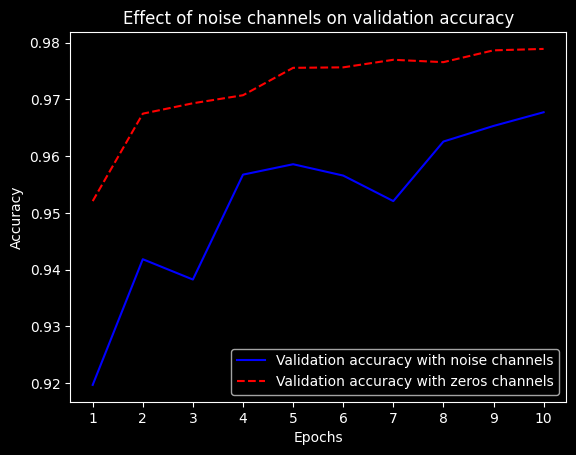

In [7]:
import matplotlib.pyplot as plt

val_acc_noise = history_noise.history["val_accuracy"]
val_acc_zeros = history_zeros.history["val_accuracy"]
epochs = range(1, 11)
plt.plot(
    epochs,
    val_acc_noise,
    "b-",
    label="Validation accuracy with noise channels",
)
plt.plot(
    epochs,
    val_acc_zeros,
    "r--",
    label="Validation accuracy with zeros channels",
)
plt.title("Effect of noise channels on validation accuracy")
plt.xlabel("Epochs")
plt.xticks(epochs)
plt.ylabel("Accuracy")
plt.legend()
plt.show()

#### The nature of generalization in deep learning

In [8]:
(train_images, train_labels), _ = mnist.load_data()
train_images = train_images.reshape((60000, 28 * 28))
train_images = train_images.astype("float32") / 255

random_train_labels = train_labels[:]
np.random.shuffle(random_train_labels)

model = keras.Sequential(
    [
        layers.Dense(512, activation="relu"),
        layers.Dense(10, activation="softmax"),
    ]
)
model.compile(
    optimizer="rmsprop",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"],
)
model.fit(
    train_images,
    random_train_labels,
    epochs=100,
    batch_size=128,
    validation_split=0.2,
)

Epoch 1/100
375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.1030 - loss: 2.3152 - val_accuracy: 0.1005 - val_loss: 2.3052
Epoch 2/100
375/375 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.1179 - loss: 2.2995 - val_accuracy: 0.1010 - val_loss: 2.3074
Epoch 3/100
375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - accuracy: 0.1291 - loss: 2.2916 - val_accuracy: 0.1036 - val_loss: 2.3188
Epoch 4/100
375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - accuracy: 0.1411 - loss: 2.2797 - val_accuracy: 0.1033 - val_loss: 2.3216
Epoch 5/100
375/375 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.1513 - loss: 2.2648 - val_accuracy: 0.1007 - val_loss: 2.3328
Epoch 6/100
375/375 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.1635 - loss: 2.2451 - val_accuracy: 0.1051 - val_loss: 2.3465
Epoch 7/100
375/375 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.1778 - loss: 2.2229 - val_accuracy: 0.1038 - val_loss: 2.3623
Epoch 8/100
375/375 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.1976 - loss: 2.1956 - val_accu

##### The manifold hypothesis

##### Interpolation as a source of generalization

##### Why deep learning works

##### Training data is paramount

### Evaluating machine-learning models

#### Training, validation, and test sets

##### Simple hold-out validation

##### K-fold validation

##### Iterated K-fold validation with shuffling

#### Beating a common-sense baseline

#### Things to keep in mind about model evaluation

### Improving model fit

#### Tuning key gradient descent parameters

In [9]:
(train_images, train_labels), _ = mnist.load_data()
train_images = train_images.reshape((60000, 28 * 28))
train_images = train_images.astype("float32") / 255

model = keras.Sequential(
    [
        layers.Dense(512, activation="relu"),
        layers.Dense(10, activation="softmax"),
    ]
)
model.compile(
    optimizer=keras.optimizers.RMSprop(learning_rate=1.0),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"],
)
model.fit(
    train_images, train_labels, epochs=10, batch_size=128, validation_split=0.2
)

Epoch 1/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.0999 - loss: 14.4753 - val_accuracy: 0.0956 - val_loss: 14.5775
Epoch 2/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.1000 - loss: 14.5056 - val_accuracy: 0.0956 - val_loss: 14.5775
Epoch 3/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.1000 - loss: 14.5056 - val_accuracy: 0.0956 - val_loss: 14.5775
Epoch 4/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.1000 - loss: 14.5056 - val_accuracy: 0.0956 - val_loss: 14.5775
Epoch 5/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.1000 - loss: 14.5056 - val_accuracy: 0.0956 - val_loss: 14.5775
Epoch 6/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.1000 - loss: 14.5056 - val_accuracy: 0.0956 - val_loss: 14.5775
Epoch 7/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.1000 - loss: 14.5056 - val_accuracy: 0.0956 - val_loss: 14.5775
Epoch 8/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.1000 - loss: 14.5056 - v

In [10]:
model = keras.Sequential(
    [
        layers.Dense(512, activation="relu"),
        layers.Dense(10, activation="softmax"),
    ]
)
model.compile(
    optimizer=keras.optimizers.RMSprop(learning_rate=1e-2),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"],
)
model.fit(
    train_images, train_labels, epochs=10, batch_size=128, validation_split=0.2
)

Epoch 1/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9085 - loss: 0.3978 - val_accuracy: 0.9592 - val_loss: 0.1472
Epoch 2/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.9655 - loss: 0.1258 - val_accuracy: 0.9643 - val_loss: 0.1437
Epoch 3/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - accuracy: 0.9740 - loss: 0.0968 - val_accuracy: 0.9680 - val_loss: 0.1608
Epoch 4/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.9791 - loss: 0.0815 - val_accuracy: 0.9670 - val_loss: 0.1690
Epoch 5/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.9827 - loss: 0.0685 - val_accuracy: 0.9732 - val_loss: 0.1463
Epoch 6/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.9851 - loss: 0.0601 - val_accuracy: 0.9710 - val_loss: 0.1654
Epoch 7/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.9868 - loss: 0.0576 - val_accuracy: 0.9739 - val_loss: 0.1704
Epoch 8/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.9893 - loss: 0.0471 - val_accuracy: 0.

#### Using better architecture priors

#### Increasing model capacity

In [11]:
model = keras.Sequential([layers.Dense(10, activation="softmax")])
model.compile(
    optimizer="rmsprop",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"],
)
history_small_model = model.fit(
    train_images, train_labels, epochs=20, batch_size=128, validation_split=0.2
)

Epoch 1/20
375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.8352 - loss: 0.6655 - val_accuracy: 0.9018 - val_loss: 0.3629
Epoch 2/20
375/375 ━━━━━━━━━━━━━━━━━━━━ 0s 277us/step - accuracy: 0.9021 - loss: 0.3538 - val_accuracy: 0.9142 - val_loss: 0.3102
Epoch 3/20
375/375 ━━━━━━━━━━━━━━━━━━━━ 0s 276us/step - accuracy: 0.9110 - loss: 0.3183 - val_accuracy: 0.9188 - val_loss: 0.2913
Epoch 4/20
375/375 ━━━━━━━━━━━━━━━━━━━━ 0s 299us/step - accuracy: 0.9157 - loss: 0.3023 - val_accuracy: 0.9216 - val_loss: 0.2834
Epoch 5/20
375/375 ━━━━━━━━━━━━━━━━━━━━ 0s 271us/step - accuracy: 0.9183 - loss: 0.2925 - val_accuracy: 0.9236 - val_loss: 0.2780
Epoch 6/20
375/375 ━━━━━━━━━━━━━━━━━━━━ 0s 268us/step - accuracy: 0.9202 - loss: 0.2855 - val_accuracy: 0.9243 - val_loss: 0.2731
Epoch 7/20
375/375 ━━━━━━━━━━━━━━━━━━━━ 0s 273us/step - accuracy: 0.9221 - loss: 0.2808 - val_accuracy: 0.9258 - val_loss: 0.2713
Epoch 8/20
375/375 ━━━━━━━━━━━━━━━━━━━━ 0s 323us/step - accuracy: 0.9229 - loss: 0.2765 - va

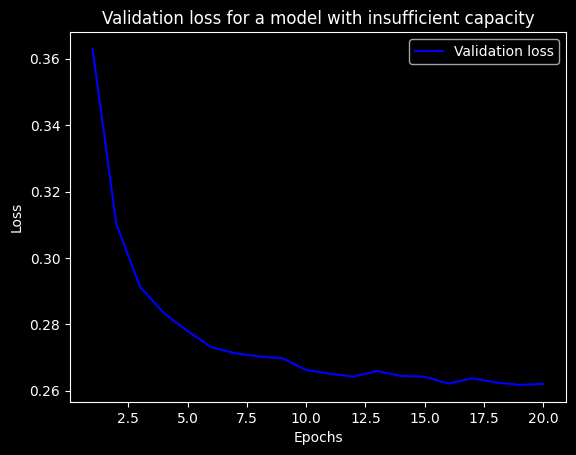

In [12]:
import matplotlib.pyplot as plt

val_loss = history_small_model.history["val_loss"]
epochs = range(1, 21)
plt.plot(epochs, val_loss, "b-", label="Validation loss")
plt.title("Validation loss for a model with insufficient capacity")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.legend()
plt.show()

In [13]:
model = keras.Sequential(
    [
        layers.Dense(128, activation="relu"),
        layers.Dense(128, activation="relu"),
        layers.Dense(10, activation="softmax"),
    ]
)
model.compile(
    optimizer="rmsprop",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"],
)
history_large_model = model.fit(
    train_images,
    train_labels,
    epochs=20,
    batch_size=128,
    validation_split=0.2,
)

Epoch 1/20
375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9021 - loss: 0.3418 - val_accuracy: 0.9533 - val_loss: 0.1644
Epoch 2/20
375/375 ━━━━━━━━━━━━━━━━━━━━ 0s 676us/step - accuracy: 0.9574 - loss: 0.1402 - val_accuracy: 0.9599 - val_loss: 0.1322
Epoch 3/20
375/375 ━━━━━━━━━━━━━━━━━━━━ 0s 721us/step - accuracy: 0.9710 - loss: 0.0962 - val_accuracy: 0.9661 - val_loss: 0.1078
Epoch 4/20
375/375 ━━━━━━━━━━━━━━━━━━━━ 0s 678us/step - accuracy: 0.9778 - loss: 0.0727 - val_accuracy: 0.9722 - val_loss: 0.0940
Epoch 5/20
375/375 ━━━━━━━━━━━━━━━━━━━━ 0s 756us/step - accuracy: 0.9822 - loss: 0.0569 - val_accuracy: 0.9697 - val_loss: 0.0997
Epoch 6/20
375/375 ━━━━━━━━━━━━━━━━━━━━ 0s 715us/step - accuracy: 0.9863 - loss: 0.0451 - val_accuracy: 0.9764 - val_loss: 0.0846
Epoch 7/20
375/375 ━━━━━━━━━━━━━━━━━━━━ 0s 667us/step - accuracy: 0.9886 - loss: 0.0360 - val_accuracy: 0.9728 - val_loss: 0.0958
Epoch 8/20
375/375 ━━━━━━━━━━━━━━━━━━━━ 0s 714us/step - accuracy: 0.9905 - loss: 0.0299 - va

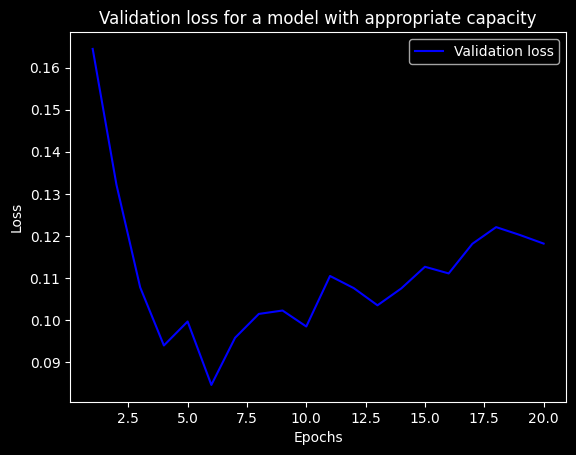

In [14]:
val_loss = history_large_model.history["val_loss"]
epochs = range(1, 21)
plt.plot(epochs, val_loss, "b-", label="Validation loss")
plt.title("Validation loss for a model with appropriate capacity")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.legend()
plt.show()

In [15]:
model = keras.Sequential(
    [
        layers.Dense(2048, activation="relu"),
        layers.Dense(2048, activation="relu"),
        layers.Dense(2048, activation="relu"),
        layers.Dense(10, activation="softmax"),
    ]
)
model.compile(
    optimizer="rmsprop",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"],
)
history_very_large_model = model.fit(
    train_images,
    train_labels,
    epochs=20,
    batch_size=32,
    validation_split=0.2,
)

Epoch 1/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 15s 10ms/step - accuracy: 0.9268 - loss: 0.2580 - val_accuracy: 0.9613 - val_loss: 0.1311
Epoch 2/20
  77/1500 ━━━━━━━━━━━━━━━━━━━━ 13s 9ms/step - accuracy: 0.9724 - loss: 0.0823

KeyboardInterrupt: 

In [16]:
val_loss = history_very_large_model.history["val_loss"]
epochs = range(1, 21)
plt.plot(epochs, val_loss, "b-", label="Validation loss")
plt.title("Validation loss for a model with too much capacity")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.legend()
plt.show()

NameError: name 'history_very_large_model' is not defined

### Improving generalization

#### Dataset curation

#### Feature engineering

#### Using early stopping

#### Regularizing your model

##### Reducing the network's size

In [17]:
from keras.datasets import imdb

(train_data, train_labels), _ = imdb.load_data(num_words=10000)

def vectorize_sequences(sequences, dimension=10000):
    results = np.zeros((len(sequences), dimension))
    for i, sequence in enumerate(sequences):
        results[i, sequence] = 1.0
    return results

train_data = vectorize_sequences(train_data)

model = keras.Sequential(
    [
        layers.Dense(16, activation="relu"),
        layers.Dense(16, activation="relu"),
        layers.Dense(1, activation="sigmoid"),
    ]
)
model.compile(
    optimizer="rmsprop",
    loss="binary_crossentropy",
    metrics=["accuracy"],
)
history_original = model.fit(
    train_data,
    train_labels,
    epochs=20,
    batch_size=512,
    validation_split=0.4,
)

17464789/17464789 ━━━━━━━━━━━━━━━━━━━━ 12s 1us/step
Epoch 1/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 16ms/step - accuracy: 0.7710 - loss: 0.5287 - val_accuracy: 0.8690 - val_loss: 0.3893
Epoch 2/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.8947 - loss: 0.3201 - val_accuracy: 0.8842 - val_loss: 0.3108
Epoch 3/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.9219 - loss: 0.2384 - val_accuracy: 0.8774 - val_loss: 0.3072
Epoch 4/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.9341 - loss: 0.1948 - val_accuracy: 0.8859 - val_loss: 0.2814
Epoch 5/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.9476 - loss: 0.1627 - val_accuracy: 0.8873 - val_loss: 0.2817
Epoch 6/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.9561 - loss: 0.1388 - val_accuracy: 0.8859 - val_loss: 0.2858
Epoch 7/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.9636 - loss: 0.1177 - val_accuracy: 0.8828 - val_loss: 0.3057
Epoch 8/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.9

In [18]:
model = keras.Sequential(
    [
        layers.Dense(4, activation="relu"),
        layers.Dense(4, activation="relu"),
        layers.Dense(1, activation="sigmoid"),
    ]
)
model.compile(
    optimizer="rmsprop",
    loss="binary_crossentropy",
    metrics=["accuracy"],
)
history_smaller_model = model.fit(
    train_data,
    train_labels,
    epochs=20,
    batch_size=512,
    validation_split=0.4,
)

Epoch 1/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 17ms/step - accuracy: 0.6918 - loss: 0.6148 - val_accuracy: 0.7550 - val_loss: 0.5605
Epoch 2/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.8062 - loss: 0.5290 - val_accuracy: 0.8361 - val_loss: 0.5189
Epoch 3/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.8547 - loss: 0.4854 - val_accuracy: 0.8407 - val_loss: 0.4922
Epoch 4/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8812 - loss: 0.4550 - val_accuracy: 0.8068 - val_loss: 0.4887
Epoch 5/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.9013 - loss: 0.4309 - val_accuracy: 0.8494 - val_loss: 0.4667
Epoch 6/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.9153 - loss: 0.4115 - val_accuracy: 0.8586 - val_loss: 0.4575
Epoch 7/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.9271 - loss: 0.3941 - val_accuracy: 0.8596 - val_loss: 0.4531
Epoch 8/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.9372 - loss: 0.3783 - val_accuracy: 0.8640 - val_loss

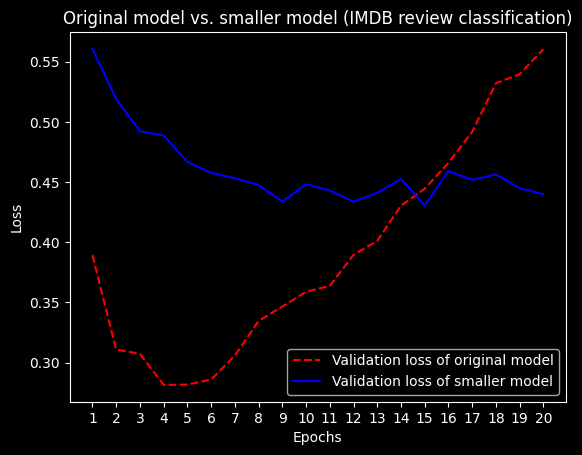

In [19]:
original_val_loss = history_original.history["val_loss"]
smaller_model_val_loss = history_smaller_model.history["val_loss"]
epochs = range(1, 21)
plt.plot(
    epochs,
    original_val_loss,
    "r--",
    label="Validation loss of original model",
)
plt.plot(
    epochs,
    smaller_model_val_loss,
    "b-",
    label="Validation loss of smaller model",
)
plt.title("Original model vs. smaller model (IMDB review classification)")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.xticks(epochs)
plt.legend()
plt.show()

In [20]:
model = keras.Sequential(
    [
        layers.Dense(512, activation="relu"),
        layers.Dense(512, activation="relu"),
        layers.Dense(1, activation="sigmoid"),
    ]
)
model.compile(
    optimizer="rmsprop",
    loss="binary_crossentropy",
    metrics=["accuracy"],
)
history_larger_model = model.fit(
    train_data,
    train_labels,
    epochs=20,
    batch_size=512,
    validation_split=0.4,
)

Epoch 1/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 39ms/step - accuracy: 0.7163 - loss: 0.5645 - val_accuracy: 0.8383 - val_loss: 0.3876
Epoch 2/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 28ms/step - accuracy: 0.8750 - loss: 0.3163 - val_accuracy: 0.8849 - val_loss: 0.2862
Epoch 3/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 31ms/step - accuracy: 0.9103 - loss: 0.2284 - val_accuracy: 0.8593 - val_loss: 0.3435
Epoch 4/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 31ms/step - accuracy: 0.9287 - loss: 0.1851 - val_accuracy: 0.8907 - val_loss: 0.2771
Epoch 5/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 30ms/step - accuracy: 0.9407 - loss: 0.1521 - val_accuracy: 0.8784 - val_loss: 0.3132
Epoch 6/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 29ms/step - accuracy: 0.9637 - loss: 0.1022 - val_accuracy: 0.8752 - val_loss: 0.3651
Epoch 7/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 28ms/step - accuracy: 0.9756 - loss: 0.0720 - val_accuracy: 0.8843 - val_loss: 0.3687
Epoch 8/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 31ms/step - accuracy: 0.9793 - loss: 0.0675 - val_accuracy: 0.8815 - v

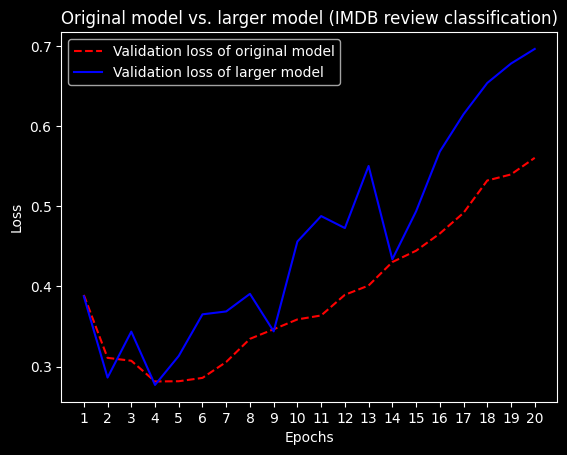

In [21]:
original_val_loss = history_original.history["val_loss"]
larger_model_val_loss = history_larger_model.history["val_loss"]
epochs = range(1, 21)
plt.plot(
    epochs,
    original_val_loss,
    "r--",
    label="Validation loss of original model",
)
plt.plot(
    epochs,
    larger_model_val_loss,
    "b-",
    label="Validation loss of larger model",
)
plt.title("Original model vs. larger model (IMDB review classification)")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.xticks(epochs)
plt.legend()
plt.show()

##### Adding weight regularization

In [22]:
from keras.regularizers import l2

model = keras.Sequential(
    [
        layers.Dense(16, kernel_regularizer=l2(0.002), activation="relu"),
        layers.Dense(16, kernel_regularizer=l2(0.002), activation="relu"),
        layers.Dense(1, activation="sigmoid"),
    ]
)
model.compile(
    optimizer="rmsprop",
    loss="binary_crossentropy",
    metrics=["accuracy"],
)
history_l2_reg = model.fit(
    train_data,
    train_labels,
    epochs=20,
    batch_size=512,
    validation_split=0.4,
)

Epoch 1/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 18ms/step - accuracy: 0.7693 - loss: 0.6044 - val_accuracy: 0.8676 - val_loss: 0.4638
Epoch 2/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.8947 - loss: 0.3967 - val_accuracy: 0.8718 - val_loss: 0.4079
Epoch 3/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.9134 - loss: 0.3312 - val_accuracy: 0.8857 - val_loss: 0.3734
Epoch 4/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.9271 - loss: 0.2942 - val_accuracy: 0.8606 - val_loss: 0.4191
Epoch 5/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.9327 - loss: 0.2760 - val_accuracy: 0.8887 - val_loss: 0.3609
Epoch 6/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.9415 - loss: 0.2570 - val_accuracy: 0.8733 - val_loss: 0.3938
Epoch 7/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.9403 - loss: 0.2532 - val_accuracy: 0.8648 - val_loss: 0.4249
Epoch 8/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.9469 - loss: 0.2421 - val_accuracy: 0.8791 - val_loss

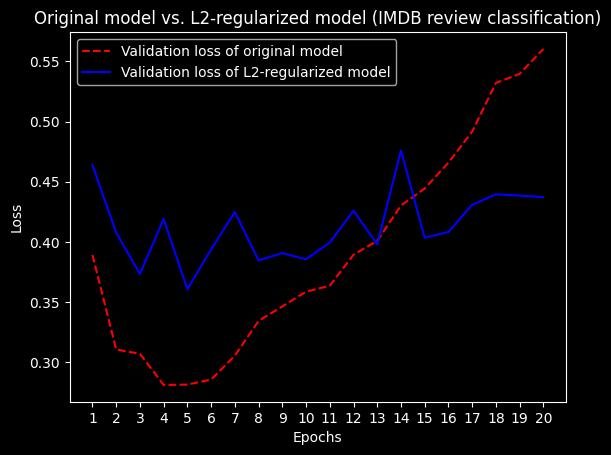

In [23]:
original_val_loss = history_original.history["val_loss"]
l2_val_loss = history_l2_reg.history["val_loss"]
epochs = range(1, 21)
plt.plot(
    epochs,
    original_val_loss,
    "r--",
    label="Validation loss of original model",
)
plt.plot(
    epochs,
    l2_val_loss,
    "b-",
    label="Validation loss of L2-regularized model",
)
plt.title(
    "Original model vs. L2-regularized model (IMDB review classification)"
)
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.xticks(epochs)
plt.legend()
plt.show()

In [24]:
from keras import regularizers

regularizers.l1(0.001)
regularizers.l1_l2(l1=0.001, l2=0.001)

##### Adding dropout

In [25]:
model = keras.Sequential(
    [
        layers.Dense(16, activation="relu"),
        layers.Dropout(0.5),
        layers.Dense(16, activation="relu"),
        layers.Dropout(0.5),
        layers.Dense(1, activation="sigmoid"),
    ]
)
model.compile(
    optimizer="rmsprop",
    loss="binary_crossentropy",
    metrics=["accuracy"],
)
history_dropout = model.fit(
    train_data,
    train_labels,
    epochs=20,
    batch_size=512,
    validation_split=0.4,
)

Epoch 1/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 18ms/step - accuracy: 0.6537 - loss: 0.6214 - val_accuracy: 0.8295 - val_loss: 0.4959
Epoch 2/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.7751 - loss: 0.4994 - val_accuracy: 0.8597 - val_loss: 0.4097
Epoch 3/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.8265 - loss: 0.4175 - val_accuracy: 0.8800 - val_loss: 0.3398
Epoch 4/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.8587 - loss: 0.3558 - val_accuracy: 0.8845 - val_loss: 0.3032
Epoch 5/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.8831 - loss: 0.3105 - val_accuracy: 0.8903 - val_loss: 0.2812
Epoch 6/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.9007 - loss: 0.2747 - val_accuracy: 0.8910 - val_loss: 0.2755
Epoch 7/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.9145 - loss: 0.2418 - val_accuracy: 0.8922 - val_loss: 0.2750
Epoch 8/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.9270 - loss: 0.2113 - val_accuracy: 0.8896 - val_loss

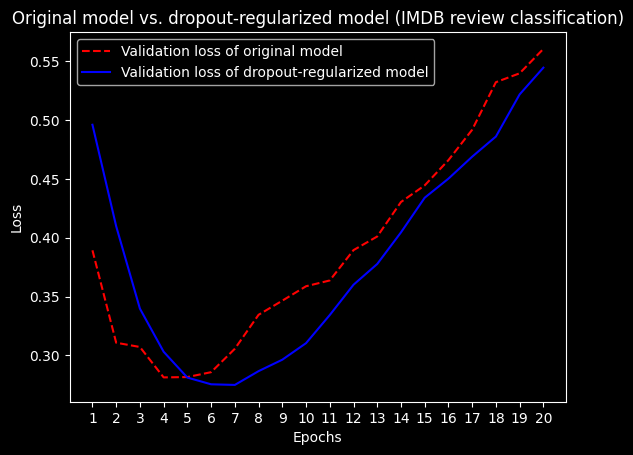

In [26]:
original_val_loss = history_original.history["val_loss"]
dropout_val_loss = history_dropout.history["val_loss"]
epochs = range(1, 21)
plt.plot(
    epochs,
    original_val_loss,
    "r--",
    label="Validation loss of original model",
)
plt.plot(
    epochs,
    dropout_val_loss,
    "b-",
    label="Validation loss of dropout-regularized model",
)
plt.title(
    "Original model vs. dropout-regularized model (IMDB review classification)"
)
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.xticks(epochs)
plt.legend()
plt.show()